# Comparative Study of Binary-Image Transformations for CNN-Based Malware Detection

This notebook evaluates four binary-to-image transformation techniques for detecting malware using CNN transfer learning:

| Index | Dataset | Description |
|-------|---------|-------------|
| 0 | DatasetBB | Binary visualisation (raw byte-to-pixel) |
| 1 | DatasetByteClass | Byte-class colour mapping |
| 2 | DatasetEntropy | Entropy-based visualisation |
| 3 | DatasetHybrid | Hybrid transformation (used in this run) |

Each dataset contains **4 000 samples** (50 % malware / 50 % benign) represented as images.  
Three pre-trained CNN architectures are fine-tuned and compared: **VGG16**, **ResNet50**, **DenseNet201**.

> **Note:** A known `AttributeError: 'MessageFactory' has no attribute 'GetPrototype'` may appear when importing TensorBoard-related protobuf utilities with certain library versions. It does not affect training.


## 1. Imports

In [1]:
# ── Standard library & data science utilities ────────────────────────────────
import os
import random
import shutil
import warnings
from pathlib import Path
from random import randint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# ── Scikit-learn metrics ──────────────────────────────────────────────────────
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
)

# ── TensorFlow / Keras core ───────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import models, regularizers, optimizers, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, Dense, MaxPooling2D, Flatten,
    Dropout, BatchNormalization,
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Pre-trained CNN architectures & their paired preprocessing functions ──────
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess

from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input as densenet201_preprocess


2026-06-04 09:37:07.647000: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780565827.841107      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780565827.896848      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780565828.322437      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780565828.322480      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780565828.322483      58 computation_placer.cc:177] computation placer alr

## 2. Dataset Paths & Configuration

In [2]:
# ── Source directories (raw, unsplit datasets on Kaggle input) ───────────────
# Each entry corresponds to one transformation technique.
source_dir = [
    "/kaggle/input/dataset-binary-conv/DatasetBB",          # 0 – Binary visualisation
    "/kaggle/input/dataset-byteclass-conv/DatasetByteClass", # 1 – Byte-class mapping
    "/kaggle/input/dataset-entropy-conv/DatasetEntropy",     # 2 – Entropy visualisation
    "/kaggle/input/dataset-hybrid-conv/DatasetHybrid",       # 3 – Hybrid transformation
]

# ── Destination directories for the train / val / test splits ─────────────────
# These are written to Kaggle's writable /kaggle/working folder.
base_dir = [
    "/kaggle/working/DatasetBB_split",
    "/kaggle/working/DatasetByteClass_split",
    "/kaggle/working/DatasetEntropy_split",
    "/kaggle/working/DatasetHybrid_split",
]

# ── Class labels (subfolder names inside each split) ─────────────────────────
classes = ["benign", "malware"]


## 3. Train / Validation / Test Split

Images are randomly shuffled and distributed into three subsets:
- **Train** – 70 % of each class
- **Validation** – 15 % of each class
- **Test** – remaining 15 %

The loop index `range(3, 4)` selects only the **Hybrid** dataset (index 3).  
Change the range to `range(len(source_dir))` to process all four datasets at once.


In [3]:
# ── Split ratios (must sum to 1.0) ───────────────────────────────────────────
train_split = 0.70
val_split   = 0.15
test_split  = 0.15   # implicitly: whatever remains after train + val

# ── Process one dataset at a time (index 3 = Hybrid) ─────────────────────────
# Change range(3, 4) to range(len(source_dir)) to rebuild all four datasets.
for i in range(3, 4):

    # 1. Create the output directory tree: base_dir/split/class/
    for split in ["train", "val", "test"]:
        for cls in classes:
            path = os.path.join(base_dir[i], split, cls)
            os.makedirs(path, exist_ok=True)  # exist_ok prevents errors on re-runs

    # 2. For each class, shuffle images and copy into split folders
    for cls in classes:
        cls_dir = os.path.join(source_dir[i], cls)
        images  = os.listdir(cls_dir)
        random.shuffle(images)  # shuffle in-place to randomise splits

        total     = len(images)
        train_end = int(total * train_split)
        val_end   = train_end + int(total * val_split)

        # Slice the shuffled list into three non-overlapping subsets
        train_imgs = images[:train_end]
        val_imgs   = images[train_end:val_end]
        test_imgs  = images[val_end:]

        # Copy each subset to its respective destination folder
        for img in train_imgs:
            shutil.copy(os.path.join(cls_dir, img), os.path.join(base_dir[i], "train", cls))
        for img in val_imgs:
            shutil.copy(os.path.join(cls_dir, img), os.path.join(base_dir[i], "val", cls))
        for img in test_imgs:
            shutil.copy(os.path.join(cls_dir, img), os.path.join(base_dir[i], "test", cls))

    print("Dataset successfully split!")
    print("New dataset located at:", base_dir[i])


Dataset successfully split!
New dataset located at: /kaggle/working/DatasetHybrid_split


## 4. Select Active Dataset

In [4]:
# ── Point the pipeline at the chosen split ───────────────────────────────────
# Change select_dataset (0–3) to switch between transformation techniques.
select_dataset = 3  # 3 = Hybrid

train_path = base_dir[select_dataset] + "/train"
valid_path = base_dir[select_dataset] + "/val"
test_path  = base_dir[select_dataset] + "/test"


## 5. Custom Augmentation: Random Cutout

`random_cutout_batch` applies **Cutout regularisation** to an entire image batch.  
It zeros out `num_masks` randomly-placed square patches of size `mask_size × mask_size`,
forcing the network to learn features that are robust to partially occluded byte regions.

This technique is particularly relevant for malware images because important structural
patterns (e.g. packed sections, import tables) can appear anywhere in the image.


In [5]:
def random_cutout_batch(images, num_masks=3, mask_size=16):
    """Apply random Cutout augmentation to every image in a batch.

    For each image, `num_masks` square regions are erased (set to 0) at
    uniformly random positions.  The operation is fully differentiable-safe
    because it only involves masking, not interpolation.

    Args:
        images    : Tensor of shape [batch_size, H, W, C].
        num_masks : Number of cutout patches per image (default 3).
        mask_size : Side length of each square patch in pixels (default 16).

    Returns:
        Augmented image tensor with the same shape as the input.
    """
    h = tf.shape(images)[1]
    w = tf.shape(images)[2]
    c = tf.shape(images)[3]

    def cutout_single(image):
        """Apply cutout to one image; called via tf.map_fn."""
        for _ in range(num_masks):
            # Sample a random top-left corner for the mask patch
            y = tf.random.uniform([], 0, h - mask_size, dtype=tf.int32)
            x = tf.random.uniform([], 0, w - mask_size, dtype=tf.int32)

            # Build a full-image mask: 1 inside the patch, 0 elsewhere
            patch = tf.ones((mask_size, mask_size, c), dtype=image.dtype)
            mask  = tf.pad(
                patch,
                [[y, h - y - mask_size], [x, w - x - mask_size], [0, 0]],
                "CONSTANT",
                constant_values=0,
            )

            # Erase the patch by multiplying image by the inverted mask
            image = image * (1 - mask)
        return image

    # Apply cutout_single to every image in the batch in parallel
    return tf.map_fn(cutout_single, images)


## 6. Data Pipeline

Each dataset is loaded with `tf.keras.utils.image_dataset_from_directory` and
pre-processed via a `map` step before being fed to the model.

**Augmentation** (training set only) applies four lightweight, malware-aware transforms:
| Transform | Purpose |
|---|---|
| `GaussianNoise(0.01)` | Simulate scanning / compression artefacts |
| `RandomBrightness(0.05)` | Subtle intensity shift across the byte image |
| `RandomContrast(0.05)` | Small contrast jitter |
| `RandomCutout` (3 × 28 px) | Hide partial sections, improving generalisation |

> **Why no rotation / flip?** Malware byte images are orientation-sensitive — rotating
> a PE header would produce unrealistic inputs — so spatial transforms are intentionally omitted.


In [6]:
# ── Global pipeline hyperparameters ──────────────────────────────────────────
BATCH_SIZE  = 64
IMG_SIZE    = (224, 224)  # Input resolution expected by VGG16 / ResNet50 / DenseNet201
NUM_CLASSES = 1           # Binary classification → single sigmoid output
AUTOTUNE    = tf.data.AUTOTUNE  # Let TF choose the optimal parallelism level

# ── Malware-aware augmentation pipeline (training only) ───────────────────────
# Spatial transforms (rotation, zoom, flip) are deliberately excluded because
# binary visualisation images are position-sensitive (PE headers, sections, etc.).
data_augmentation = tf.keras.Sequential([
    layers.GaussianNoise(stddev=0.01),        # Simulate minor noise / compression artefacts
    layers.RandomBrightness(factor=0.05),     # Small intensity perturbation
    layers.RandomContrast(factor=0.05),       # Small contrast perturbation
    layers.Lambda(                            # Erase 3 random 28×28 patches per image
        lambda x: random_cutout_batch(x, num_masks=3, mask_size=28)
    ),
])

def prepare_dataset(path, augment=False):
    """Load images from a directory and build an optimised tf.data pipeline.

    Args:
        path    : Directory with class subfolders (benign/, malware/).
        augment : If True, apply data_augmentation (use for training set only).

    Returns:
        A tf.data.Dataset of (image, label) pairs, pre-fetched for performance.
    """
    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary',  # Returns float labels {0.0, 1.0}
        shuffle=augment,      # Shuffle training data; keep val/test ordered
    )

    def preprocess(image, label):
        image = tf.cast(image, tf.float32)  # Ensure float dtype for augmentation layers
        if augment:
            image = data_augmentation(image)
        return image, label

    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)  # Overlap data loading with GPU compute
    return ds

# ── Build the three splits ────────────────────────────────────────────────────
train_ds = prepare_dataset(train_path, augment=True)
val_ds   = prepare_dataset(valid_path, augment=False)
test_ds  = prepare_dataset(test_path,  augment=False)

# ── Quick shape sanity-check ──────────────────────────────────────────────────
train_iter        = iter(train_ds)
imgs, labels      = next(train_iter)
print("Batch image shape :", imgs.shape)    # Expected: (64, 224, 224, 3)
print("Batch label shape :", labels.shape)  # Expected: (64, 1)


Found 2800 files belonging to 2 classes.


I0000 00:00:1780565860.746268      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 600 files belonging to 2 classes.
Found 600 files belonging to 2 classes.
Batch image shape : (64, 224, 224, 3)
Batch label shape : (64, 1)


## 7. Sample Image Preview

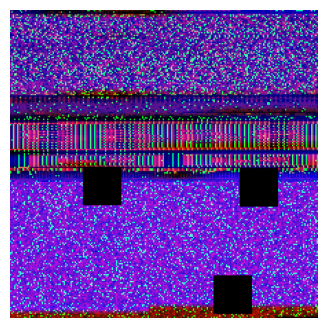

Image tensor shape: (224, 224, 3)


In [8]:
# ── Display the first image from the training batch ──────────────────────────
# Casting to uint8 is required because the raw float tensor may contain
# values outside [0, 255] after augmentation.
img_np = imgs[0].numpy().astype(np.uint8)

plt.figure(figsize=(4, 4))
plt.imshow(img_np)
plt.axis('off')
#plt.title(f"Label: {'malware' if int(labels[0]) == 1 else 'benign'}")
plt.show()

print("Image tensor shape:", imgs[0].shape)


## 8. Results Tracker

In [9]:
# ── Initialise an empty DataFrame to collect per-model evaluation results ─────
# Rows are appended inside train_tl_model() after each model finishes training.
scores_df = pd.DataFrame(columns=['Model Name', 'Accuracy', 'Loss'])
scores_df


,Model Name,Accuracy,Loss


## 9. Transfer Learning Training Loop

`train_tl_model` iterates over each (architecture, preprocessor) pair and:

1. **Builds** the model: frozen ImageNet backbone → GlobalAveragePooling → Dense(sigmoid)
2. **Trains** for up to 40 epochs with early stopping (patience = 5 on `val_loss`)
3. **Evaluates** on the held-out test set, reporting Accuracy, Loss, F1, AUC, and confusion matrix
4. **Appends** results to `scores_df` for the final comparison bar charts


In [10]:
NUM_CLASSES = 1  # Binary output: 0 = benign, 1 = malware

def train_tl_model(model_list, preprocessor_list):
    """Train, evaluate, and log results for each CNN architecture.

    For each (architecture, preprocessor) pair:
      - Freeze the ImageNet backbone (feature extraction mode)
      - Add a GlobalAveragePooling + Dense(sigmoid) classification head
      - Train with Adam + binary cross-entropy + early stopping
      - Plot training curves, ROC curve, and confusion matrix
      - Append test accuracy/loss to the global scores_df

    Args:
        model_list       : List of Keras application constructors (e.g. [VGG16, ResNet50]).
        preprocessor_list: Matching list of preprocess_input functions for each architecture.
    """
    for model_name, preprocess_func in zip(model_list, preprocessor_list):

        print()
        print(f' {model_name.__name__} '.center(50, '#'))

        # ── 1. Build model ────────────────────────────────────────────────────
        # Apply the architecture-specific preprocessing as the first Lambda layer
        # so raw pixel values are scaled correctly for each backbone.
        input_layer = tf.keras.Input((224, 224, 3))
        x           = tf.keras.layers.Lambda(preprocess_func)(input_layer)

        # Load the backbone with ImageNet weights; exclude the original top classifier
        base_model          = model_name(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
        base_model.trainable = False  # Freeze all backbone weights (feature extraction only)
        x = base_model(x)

        # Classification head: pool spatial features → single probability
        x       = tf.keras.layers.GlobalAveragePooling2D()(x)
        outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='sigmoid')(x)

        model = tf.keras.models.Model(inputs=input_layer, outputs=outputs)

        # ── 2. Compile ────────────────────────────────────────────────────────
        model.compile(
            loss='binary_crossentropy',
            optimizer='adam',
            metrics=['accuracy'],
        )

        # ── 3. Train ──────────────────────────────────────────────────────────
        early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=40,
            batch_size=BATCH_SIZE,
            callbacks=[early_stopping],
            verbose=1,
        )

        # ── 4. Training curves ────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(12, 3))
        for ax, metric in zip(axes, ['accuracy', 'loss']):
            ax.plot(history.history[metric],        label='train')
            ax.plot(history.history['val_' + metric], label='valid')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(metric.capitalize())
            ax.set_title(f'{model_name.__name__} – {metric.capitalize()}')
            ax.legend()
        plt.tight_layout()
        plt.show()

        # ── 5. Collect predictions over the test set ──────────────────────────
        y_true      = []
        y_pred_prob = []

        for batch_imgs, batch_labels in test_ds:
            preds = model.predict(batch_imgs, verbose=0)
            y_pred_prob.extend(preds.ravel())
            y_true.extend(batch_labels.numpy())

        y_true      = np.array(y_true)
        y_pred_prob = np.array(y_pred_prob)
        y_pred      = (y_pred_prob >= 0.5).astype(int)  # Hard threshold at 0.5

        # ── 6. Metrics ────────────────────────────────────────────────────────
        f1        = f1_score(y_true, y_pred)
        cm        = confusion_matrix(y_true, y_pred)
        fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
        auc_score = auc(fpr, tpr)

        print("\n===== RESULTS =====")
        print(f"F1 Score : {f1:.4f}")
        print(f"AUC      : {auc_score:.4f}")
        print("Confusion Matrix:")
        print(cm)

        # Test loss & accuracy via model.evaluate (uses the same compiled metrics)
        results = model.evaluate(test_ds, verbose=0)
        print("\n===== Test Loss / Test Accuracy =====")
        print(f"Test Loss     : {results[0]:.4f}")
        print(f"Test Accuracy : {results[1]:.4f}")

        # Append to the global comparison DataFrame
        scores_df.loc[len(scores_df)] = [model_name.__name__, results[0], results[1]]

        # ── 7. ROC Curve ──────────────────────────────────────────────────────
        print("\n===== ROC Curve =====")
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
        plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random classifier')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve – {model_name.__name__}")
        plt.legend()
        plt.show()

        # ── 8. Confusion Matrix ───────────────────────────────────────────────
        print("\n===== Confusion Matrix =====")
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        disp.plot(cmap="Blues")
        plt.title(f"Confusion Matrix – {model_name.__name__}")
        plt.show()

        print(' '.center(50, '#'))
        print()


## 10. Run Training

In [ ]:
# ── Register models and their matching preprocessing functions ───────────────
# Each preprocessor scales pixel values to the range expected by its backbone:
#   VGG16     → subtracts ImageNet channel means (BGR order)
#   ResNet50  → subtracts ImageNet channel means (BGR order)
#   DenseNet201 → scales to [-1, 1]
model_list       = [VGG16, ResNet50, DenseNet201]
preprocessor_list = [vgg16_preprocess, resnet50_preprocess, densenet201_preprocess]

# ── Start the training loop ───────────────────────────────────────────────────
# Training all three models sequentially; each run appends one row to scores_df.
train_tl_model(model_list, preprocessor_list)



##################### VGG16 ######################
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40


I0000 00:00:1780566014.544331     124 service.cc:152] XLA service 0x7a6c90014490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780566014.544383     124 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780566015.355391     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/44 ━━━━━━━━━━━━━━━━━━━━ 12:10 17s/step - accuracy: 0.4531 - loss: 1.5098

I0000 00:00:1780566029.610596     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 565ms/step - accuracy: 0.6893 - loss: 0.7888 - val_accuracy: 0.8083 - val_loss: 0.4819
Epoch 2/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step - accuracy: 0.8400 - loss: 0.3992 - val_accuracy: 0.8733 - val_loss: 0.3032
Epoch 3/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.8707 - loss: 0.3148 - val_accuracy: 0.9150 - val_loss: 0.2412
Epoch 4/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8794 - loss: 0.3031

## 11. Model Comparison

Bar charts comparing each model's **test loss** and **test accuracy** side by side.

> **Note:** The original `plot_loss` and `plot_accuracy` functions had their titles and
> column references swapped (loss plotted accuracy column and vice versa). This has been corrected below.


In [ ]:
def plot_comparison(df):
    """Plot test loss and test accuracy for all models side by side.

    Args:
        df: DataFrame with columns ['Model Name', 'Accuracy', 'Loss'].
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Test Accuracy bar chart ───────────────────────────────────────────────
    ax0 = sns.barplot(data=df, x='Model Name', y='Accuracy', palette='viridis', ax=axes[0])
    for container in ax0.containers:
        ax0.bar_label(container, fmt='%.4f')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Model Comparison – Test Accuracy')
    axes[0].tick_params(axis='x', rotation=45)

    # ── Test Loss bar chart ───────────────────────────────────────────────────
    ax1 = sns.barplot(data=df, x='Model Name', y='Loss', palette='magma', ax=axes[1])
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.4f')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Model Comparison – Test Loss')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# ── Display final comparison ──────────────────────────────────────────────────
plot_comparison(scores_df)
